In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
import shap
import warnings
warnings.filterwarnings('ignore')

In [12]:
# Veriyi okuyoruz
data = pd.read_csv('Bank Customer Churn Prediction.csv')
df = data.copy()

# İlk bakış: Verinin yapısı ve eksik değerler
print("Veri Seti İlk 5 Satır:\n", df.head())
print("\nVeri Seti Bilgileri:\n")
df.info()
print("\nTemel İstatistikler:\n", df.describe().T)
print("\nEksik Değerler:\n", df.isnull().sum())

# Hedef değişken (Churn) dağılımı
print("\nChurn Sınıf Dağılımı:\n", df["churn"].value_counts())

# Modele faydası olmayan müşteri ID'sini siliyoruz
df.drop("customer_id", axis=1, inplace=True)

Veri Seti İlk 5 Satır:
    customer_id  credit_score country  gender  age  tenure    balance  \
0     15634602           619  France  Female   42       2       0.00   
1     15647311           608   Spain  Female   41       1   83807.86   
2     15619304           502  France  Female   42       8  159660.80   
3     15701354           699  France  Female   39       1       0.00   
4     15737888           850   Spain  Female   43       2  125510.82   

   products_number  credit_card  active_member  estimated_salary  churn  
0                1            1              1         101348.88      1  
1                1            0              1         112542.58      0  
2                3            1              0         113931.57      1  
3                2            0              0          93826.63      0  
4                1            1              1          79084.10      0  

Veri Seti Bilgileri:

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns

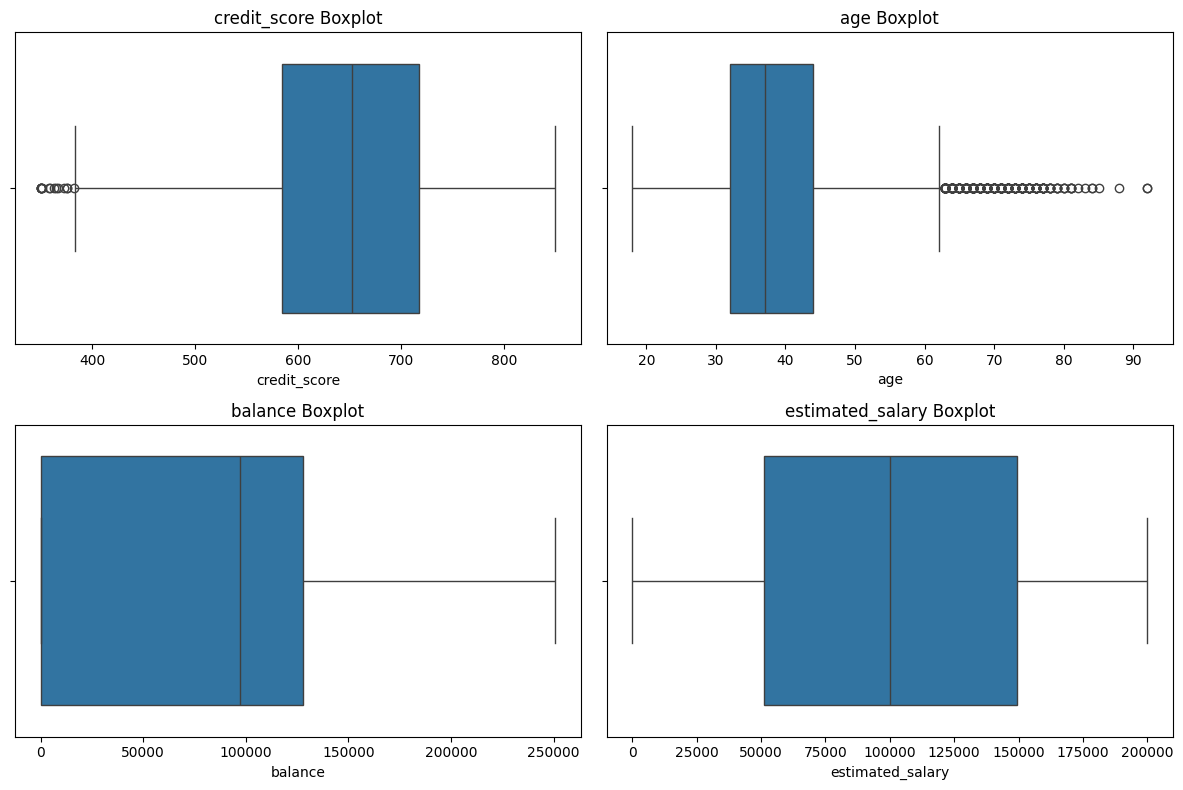

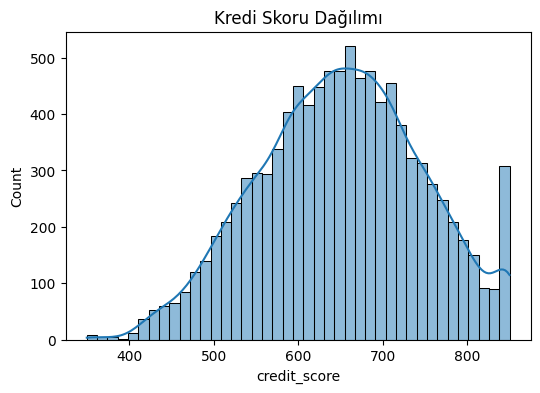

In [13]:
# Mülakat Notu: Aykırı değerlere ezbere müdahale etmeden önce, dağılımları görsel olarak inceledim.
cols = ["credit_score", "age", "balance", "estimated_salary"]

plt.figure(figsize=(12, 8))
for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i) 
    sns.boxplot(x=df[col]) 
    plt.title(f'{col} Boxplot')
plt.tight_layout()
plt.show()

# Kredi skoru histogramı (Dağılımın normal olup olmadığını görmek için)
plt.figure(figsize=(6,4))
sns.histplot(df["credit_score"], kde=True)
plt.title('Kredi Skoru Dağılımı')
plt.show()

Age: Tespit edilen aykırı değer sayısı: 359

Age ve Credit Score aykırı değerleri başarıyla baskılandı.


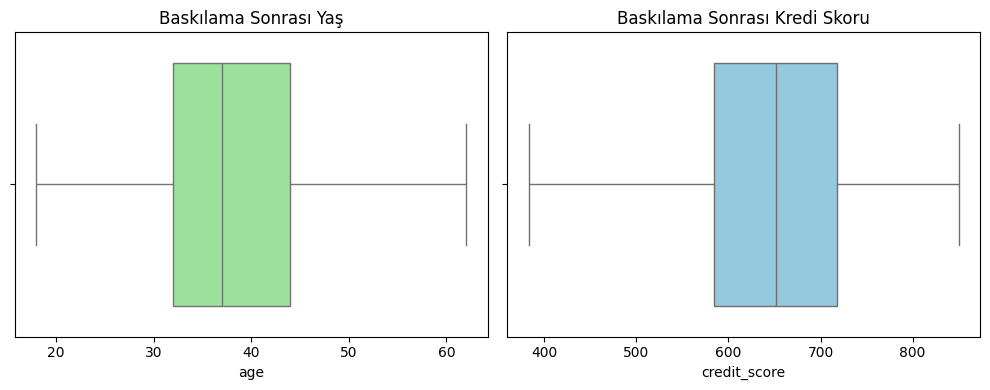

In [14]:
# 1. Yaş (Age) için IQR tabanlı baskılama
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[(df['age'] < lower_limit) | (df['age'] > upper_limit)]
print(f"Age: Tespit edilen aykırı değer sayısı: {len(outliers)}")

# np.where ile koşullu atama
df['age'] = np.where(df['age'] > upper_limit, upper_limit, 
            np.where(df['age'] < lower_limit, lower_limit, df['age']))

# 2. Kredi Skoru (Credit Score) için IQR tabanlı baskılama
Q1_cs = df['credit_score'].quantile(0.25)
Q3_cs = df['credit_score'].quantile(0.75)
IQR_cs = Q3_cs - Q1_cs
lower_limit_cs = Q1_cs - 1.5 * IQR_cs
upper_limit_cs = Q3_cs + 1.5 * IQR_cs

# np.where ile koşullu atama
df['credit_score'] = np.where(df['credit_score'] < lower_limit_cs, lower_limit_cs,
                             np.where(df['credit_score'] > upper_limit_cs, upper_limit_cs, df['credit_score']))

print("\nAge ve Credit Score aykırı değerleri başarıyla baskılandı.")

# Kontrol: Baskılama sonrası yeni Boxplot'lar
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x=df['age'], color='lightgreen')
plt.title('Baskılama Sonrası Yaş')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['credit_score'], color='skyblue')
plt.title('Baskılama Sonrası Kredi Skoru')
plt.tight_layout()
plt.show()

Balance değeri 0 olan müşteri sayısı: 3617
Balance değeri 0 olan müşterilerin churn oranı: 13.82%
Balance değeri 0 olmayan müşterilerin churn oranı: 24.08%


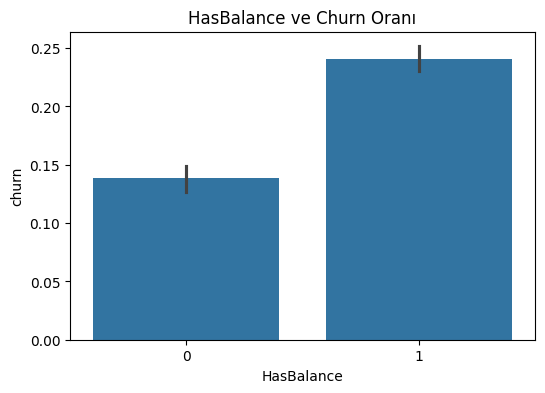

In [ ]:
# 1. Bakiye (Balance) Analizi ve Yeni Özellik Üretimi
zero = df[df["balance"] == 0]
print(f"Balance değeri 0 olan müşteri sayısı: {len(zero)}")
print(f"Balance değeri 0 olan müşterilerin churn oranı: {zero['churn'].mean():.2%}")
print(f"Balance değeri 0 olmayan müşterilerin churn oranı: {df[df['balance']!=0]['churn'].mean():.2%}")

# 'HasBalance' değişkenini oluşturma
df["HasBalance"] = df["balance"].apply(lambda x: 1 if x > 0 else 0)

plt.figure(figsize=(6,4))
sns.barplot(x="HasBalance", y="churn", data=df)
plt.title("HasBalance ve Churn Oranı")
plt.show()

# 2. Kategorik Değişkenleri Sayısallaştırma
# Gender'ı manuel map'leme 
df["gender"] = df["gender"].map({"Female": 0, " Male": 1, "Male": 1})

# Country için One-Hot Encoding
df = pd.get_dummies(df, columns=['country'], drop_first=True)

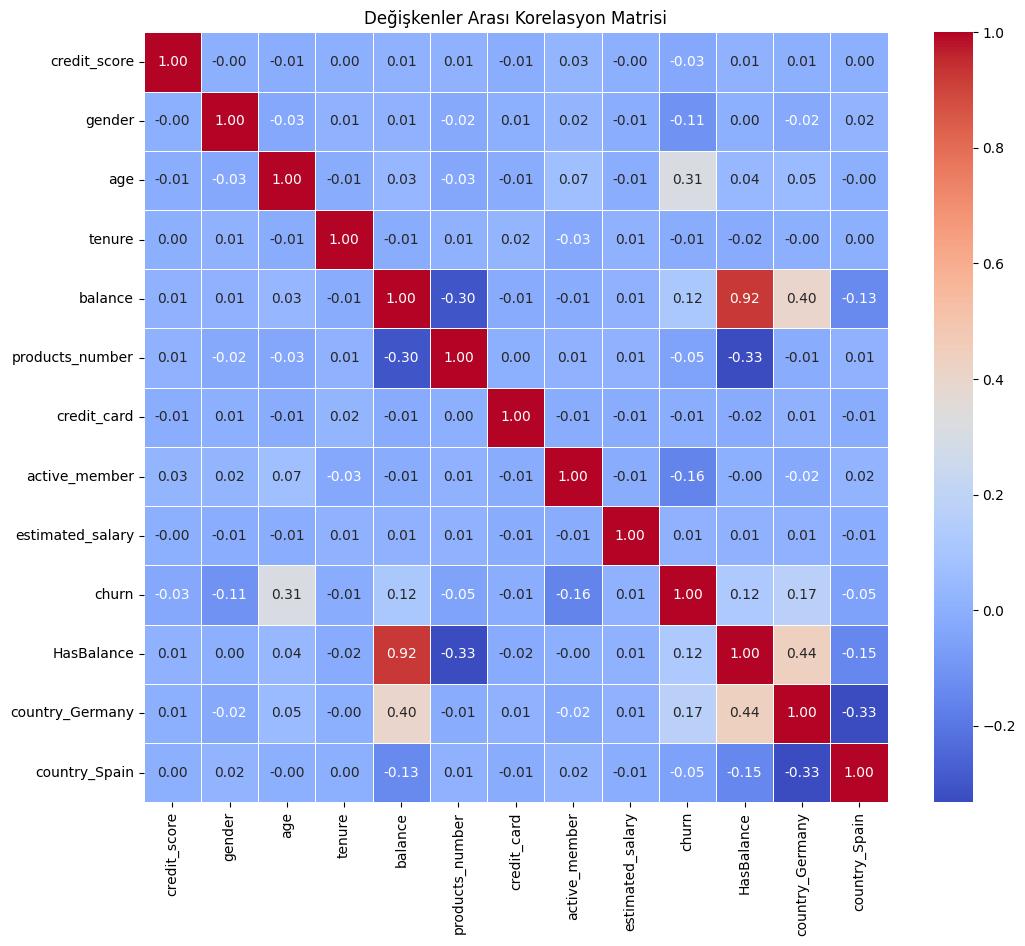

In [16]:
# Mülakat Notu: Değişkenler arası doğrusal ilişkileri görmek ve çoklu bağlantı (multicollinearity) kontrolü için
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Değişkenler Arası Korelasyon Matrisi')
plt.show()

In [19]:
# Hedef ve özellikleri ayırma
X = df.drop("churn", axis=1)
y = df["churn"]

# Veriyi bölme
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train set boyutu: {x_train.shape[0]} örnek")
print(f"Test set boyutu: {x_test.shape[0]} örnek")

# StandardScaler Uygulaması (Veriyi standartlaştırma)
# Mülakat Notu: Ağaç modelleri ölçeklendirmeye ihtiyaç duymasa da, algoritmalar arası kıyaslama yapabilmek ve iyi pratikler adına sayısal verileri standartlaştırdım.
scaler = StandardScaler()
numerical_cols = ["credit_score", "age", "balance", "estimated_salary", "tenure", "products_number"]

# Fit_transform sadece eğitim setine, transform test setine (Data Leakage'ı önlemek için)
x_train[numerical_cols] = scaler.fit_transform(x_train[numerical_cols])
x_test[numerical_cols] = scaler.transform(x_test[numerical_cols])

Train set boyutu: 8000 örnek
Test set boyutu: 2000 örnek


--- İlk Model Performans Raporu ---
              precision    recall  f1-score   support

           0       0.92      0.82      0.87      1593
           1       0.52      0.74      0.61       407

    accuracy                           0.81      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.84      0.81      0.82      2000

ROC_AUC Skoru: 0.8642


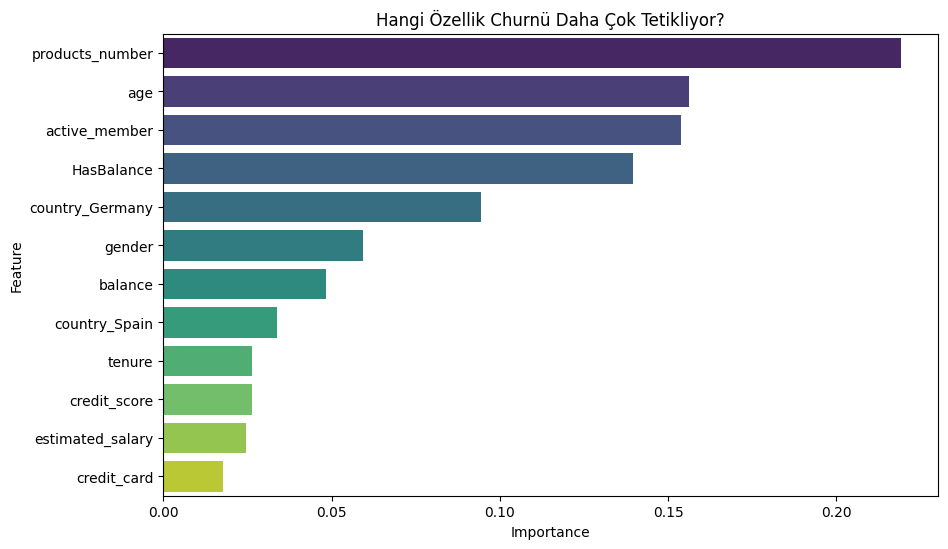

In [20]:
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=4,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
y_probs = model.predict_proba(x_test)[:,1]

print("--- İlk Model Performans Raporu ---")
print(classification_report(y_test, y_pred))
print(f"ROC_AUC Skoru: {roc_auc_score(y_test, y_probs):.4f}")

# Feature Importance Grafiği
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(ascending=False, by='Importance')

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')
plt.title('Hangi Özellik Churnü Daha Çok Tetikliyor?')
plt.show()

In [21]:
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1],
    'scale_pos_weight': [4, 5] 
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, 
                           scoring='roc_auc', cv=5, verbose=1, n_jobs=-1)

grid_search.fit(x_train, y_train)

print(f"En İyi Parametreler: {grid_search.best_params_}")
print(f"En İyi AUC Skoru: {grid_search.best_score_}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
En İyi Parametreler: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 5, 'subsample': 1}
En İyi AUC Skoru: 0.8656256320366751


--- Final Model Performans Raporu (Tuned) ---
              precision    recall  f1-score   support

           0       0.94      0.75      0.83      1593
           1       0.45      0.80      0.57       407

    accuracy                           0.76      2000
   macro avg       0.69      0.77      0.70      2000
weighted avg       0.84      0.76      0.78      2000

Final ROC_AUC Skoru: 0.8680


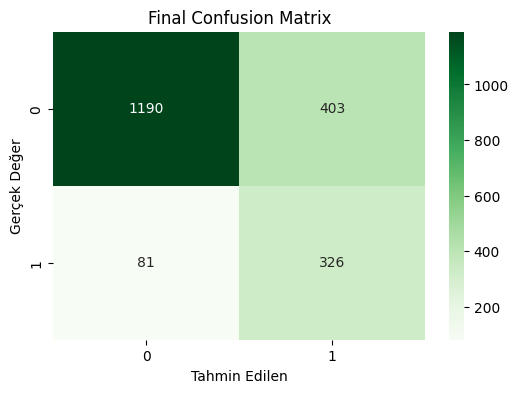

In [22]:
# Tuning sonucunda bulduğumuz en iyi ayarlarla modeli kuruyoruz
final_model = XGBClassifier(
    learning_rate=0.1,
    max_depth=3,
    n_estimators=100,
    scale_pos_weight=5,
    subsample=1,
    eval_metric='logloss',
    random_state=42
)

final_model.fit(x_train, y_train)

y_pred_final = final_model.predict(x_test)
y_probs_final = final_model.predict_proba(x_test)[:, 1]

print("--- Final Model Performans Raporu (Tuned) ---")
print(classification_report(y_test, y_pred_final))
print(f"Final ROC_AUC Skoru: {roc_auc_score(y_test, y_probs_final):.4f}")

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='Greens')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('Final Confusion Matrix')
plt.show()

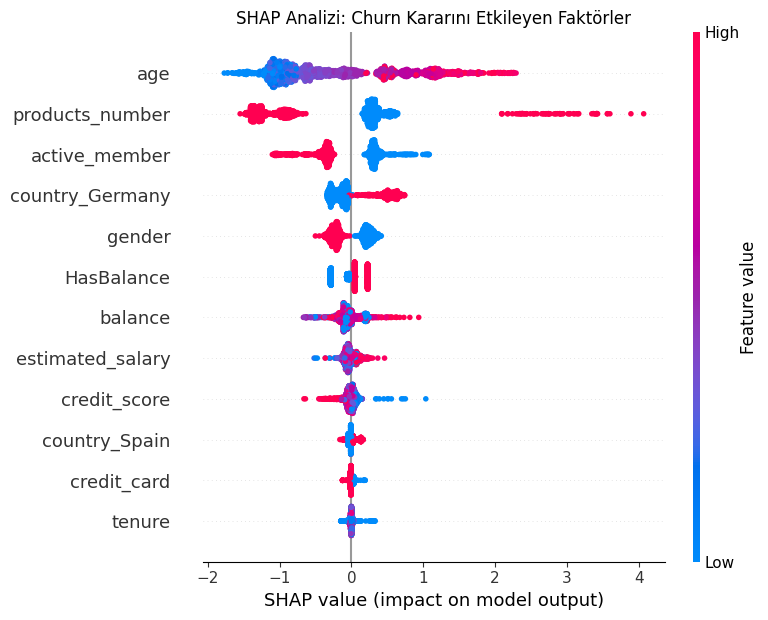

In [23]:
# Mülakat Notu: Modelin "kara kutu" olmasını engelliyor ve kararların arkasındaki matematiği görselleştiriyoruz
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(x_test)

plt.figure(figsize=(8,6))
plt.title('SHAP Analizi: Churn Kararını Etkileyen Faktörler')
shap.summary_plot(shap_values, x_test)

In [24]:
import joblib
joblib.dump(final_model, 'final_churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'model_columns.pkl')
print("Başarıyla model, scaler ve model sütunları kaydedildi!")

Başarıyla model, scaler ve model sütunları kaydedildi!


In [28]:
##Tahmin
model_tahmin=joblib.load('final_churn_model.pkl')
scaler_tahmin=joblib.load('scaler.pkl')
new_customer=([{ "gender": 1, "age": 30, "balance": 1000, "HasBalance": 1 }])
new_customer_df = pd.DataFrame(new_customer)
print("Yeni müşteri verisi:\n", new_customer_df)


Yeni müşteri verisi:
    gender  age  balance  HasBalance
0       1   30     1000           1


In [30]:
##for Power BI
powerbi_df=data.loc[x_test.index].copy()
powerbi_df["Tahmin"]=y_pred_final
powerbi_df["Churn_Rate"]=(y_probs_final*100).round(2)

powerbi_df.to_csv('powerbi_churn_predictions.csv', index=False)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,Tahmin,Churn_Rate
5702,15749540,585,France,Male,36,7,0.00,2,1,0,94283.09,0,0,8.150000
3667,15807340,525,Germany,Male,33,4,131023.76,2,0,0,55072.93,0,0,30.260000
1617,15801062,557,Spain,Female,40,4,0.00,2,0,1,105433.53,0,0,17.610001
5673,15572801,639,Spain,Male,34,5,139393.19,2,0,0,33950.08,0,0,20.740000
4272,15600708,640,Spain,Female,34,3,77826.80,1,1,1,168544.85,0,0,41.430000
